# Proyecto 5 — Recuperación y evaluación en RAG

Cuaderno técnico. Se completa de forma progresiva a lo largo de los hitos.

**Pregunta técnica:** comparar recuperación léxica (BM25), densa (embeddings) e híbrida (RRF) sobre un corpus de 100+ documentos y 30+ consultas, midiendo P@k, R@k, MRR y nDCG, más latencia y memoria, y analizando qué tipos de consulta fallan en cada método.

## 1. Datos: corpus y consultas (Hito 2)

El corpus (`data/corpus/corpus.jsonl`) reúne 595 fragmentos de 40 artículos de Wikipedia en español sobre PLN, recuperación de información y aprendizaje automático. Las consultas (`data/queries/queries.jsonl`) son 54, etiquetadas en tres tipos —**léxicas**, **semánticas** y **difíciles**— para analizar en qué casos gana cada método de recuperación. Detalle y procedencia en [`docs/datos.md`](../docs/datos.md).

Generar los datos desde cero: `python scripts/fetch_sources.py` (descarga los artículos) y `python scripts/prepare_corpus.py` (limpia y trocea).

In [1]:
import json
from pathlib import Path

DATA = Path("..") / "data"


def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]


corpus = load_jsonl(DATA / "corpus" / "corpus.jsonl")
queries = load_jsonl(DATA / "queries" / "queries.jsonl")

print(f"Fragmentos en el corpus: {len(corpus)}")
print(f"Consultas de evaluación: {len(queries)}")
print("\nEjemplo de fragmento:")
print(corpus[0])

Fragmentos en el corpus: 595
Consultas de evaluación: 54

Ejemplo de fragmento:
{'doc_id': 'analisis_grupos__c00', 'source_id': 'analisis_grupos', 'title': 'Análisis de grupos', 'text': 'Análisis de grupos o agrupamiento es la tarea de agrupar objetos por similitud, en grupos o conjuntos de manera que los miembros del mismo grupo tengan características similares. Es la tarea principal de la minería de datos exploratoria y es una técnica común en el análisis de datos estadísticos. Además es utilizada en múltiples campos comoː aprendizaje automático reconocimiento de patrones análisis de imágenes búsqueda y recuperación de información bioinformática compresión de datos computación gráfica. El análisis de grupos es un problema, es un planteamiento general, y existen miles\u200b de algoritmos que lo resuelven, cada uno con sus propias características. Muchos algoritmos difieren significativamente en su idea de qué constituye un grupo y cómo encontrarlos eficientemente. El agrupamie'}


In [2]:
import pandas as pd

df = pd.DataFrame(corpus)
df["longitud"] = df["text"].str.len()

por_fuente = (
    df.groupby("source_id")
    .agg(titulo=("title", "first"), fragmentos=("doc_id", "count"), long_media=("longitud", "mean"))
    .sort_values("fragmentos", ascending=False)
)

print(
    f"Fuentes: {df['source_id'].nunique()} | "
    f"Fragmentos: {len(df)} | "
    f"Longitud media: {df['longitud'].mean():.0f} caracteres"
)
por_fuente.round(0)

Fuentes: 40 | Fragmentos: 595 | Longitud media: 784 caracteres


,titulo,fragmentos,long_media
source_id,,,
red_neuronal,Red neuronal artificial,82,796.0
analisis_grupos,Análisis de grupos,52,794.0
traduccion_automatica,Traducción automática,37,789.0
entropia,Entropía (información),28,784.0
aprendizaje_automatico,Aprendizaje automático,25,796.0
motor_busqueda,Motor de búsqueda,24,781.0
retropropagacion,Propagación hacia atrás,24,808.0
svm,Máquina de vectores de soporte,22,808.0
analisis_sentimiento,Análisis de sentimiento,20,795.0


In [3]:
import collections

conteo = collections.Counter(q["type"] for q in queries)
print("Consultas por tipo:", dict(conteo))

# Un ejemplo de cada tipo con sus fuentes relevantes.
for tipo in ["lexica", "semantica", "dificil"]:
    ejemplo = next(q for q in queries if q["type"] == tipo)
    print(f"\n[{tipo}] {ejemplo['query']}")
    print(f"   fuentes relevantes: {ejemplo['relevant_source_ids']}")

Consultas por tipo: {'lexica': 18, 'semantica': 18, 'dificil': 18}

[lexica] función de ranking Okapi BM25
   fuentes relevantes: ['bm25']

[semantica] cómo puntuar la pertinencia de un texto frente a las palabras buscadas
   fuentes relevantes: ['bm25']

[dificil] diferencia entre recuperación por palabras clave y búsqueda semántica
   fuentes relevantes: ['recuperacion_informacion', 'busqueda_semantica']


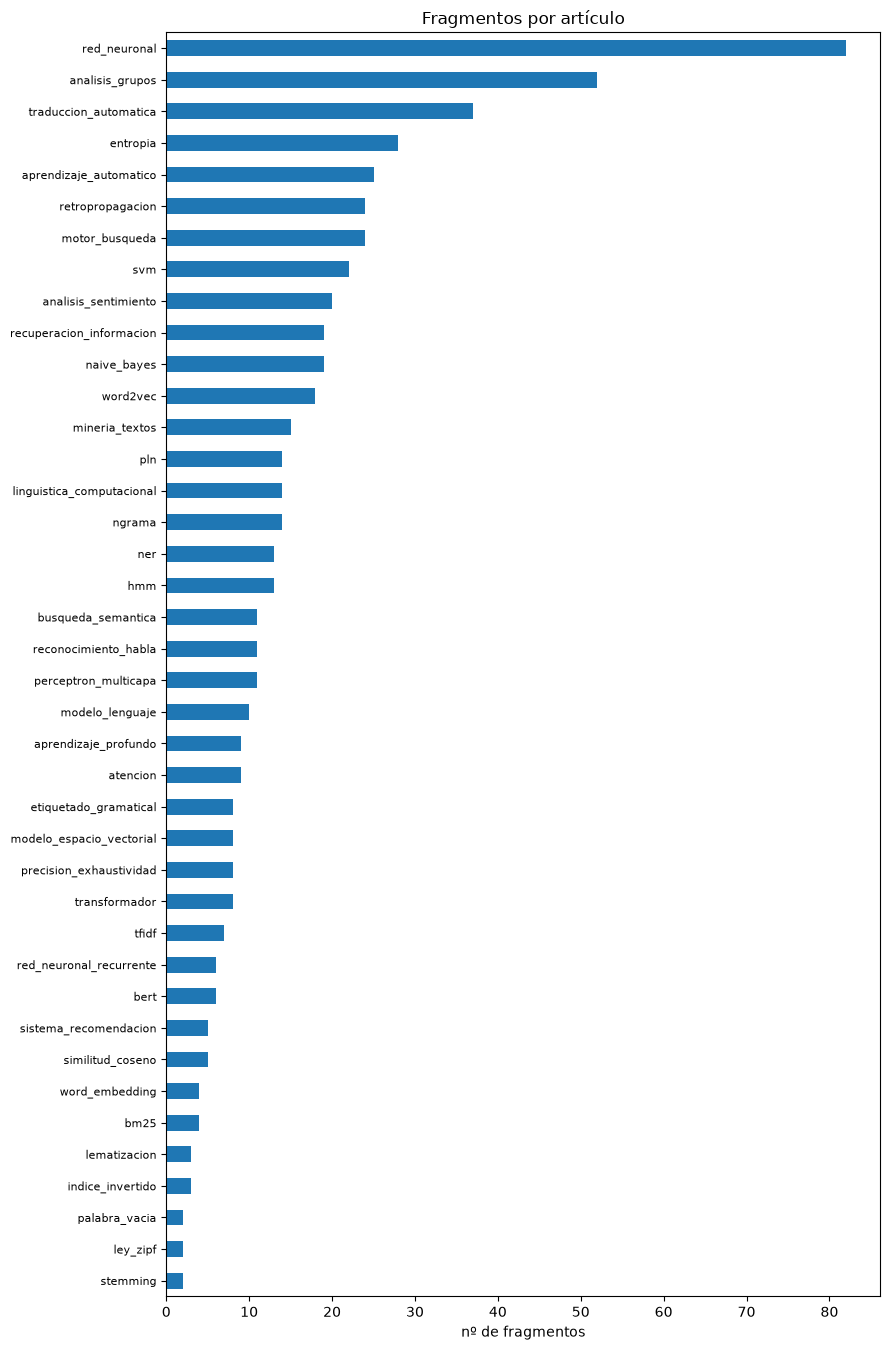

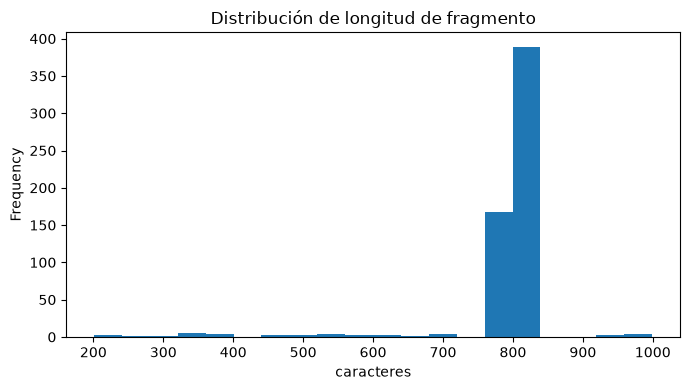

In [4]:
import matplotlib.pyplot as plt

orden = por_fuente["fragmentos"].sort_values()
fig, ax = plt.subplots(figsize=(9, max(6, 0.34 * len(orden))))
orden.plot.barh(ax=ax)
ax.set_title("Fragmentos por artículo")
ax.set_xlabel("nº de fragmentos")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

# Histograma de longitudes en una figura aparte.
fig, ax = plt.subplots(figsize=(7, 4))
df["longitud"].plot.hist(bins=20, ax=ax)
ax.set_title("Distribución de longitud de fragmento")
ax.set_xlabel("caracteres")
plt.tight_layout()
plt.show()

## 2. Línea base BM25 y métricas (Hito 3)

### 2.1 El algoritmo

Okapi BM25 puntúa un documento $D$ frente a una consulta $Q$ sumando, término a término:

$$\text{score}(D, Q) = \sum_{t \in Q} \mathrm{IDF}(t) \cdot \frac{f(t, D)\,(k_1 + 1)}{f(t, D) + k_1\left(1 - b + b\,\dfrac{|D|}{\overline{|D|}}\right)}$$

Cada pieza corrige un defecto de contar palabras a secas:

- **IDF** — un término raro en el corpus ("okapi") informa más que uno frecuente ("modelo"); la frecuencia inversa de documento pondera cada coincidencia por lo informativa que es.
- **$k_1 = 1.5$ (saturación)** — la quinta repetición de un término vale menos que la primera: la ganancia por frecuencia crece pero se aplana, en lugar de crecer linealmente.
- **$b = 0.75$ (normalización por longitud)** — un fragmento más largo que el promedio ($\overline{|D|}$) necesita más coincidencias para el mismo puntaje; sin esto, los documentos largos ganarían solo por tener más palabras.

La implementación ([`src/rag_retrieval/retrieval/bm25.py`](../src/rag_retrieval/retrieval/bm25.py)) usa `rank_bm25.BM25Okapi` siguiendo el patrón del Cuaderno 21 del curso (semana 10); la explicación de la fórmula sigue el BM25 simplificado del Cuaderno 23 (semana 11). La **tokenización es propia**: minúsculas, sin tildes y palabras `\w+`, aplicada idéntica a corpus y consultas — lo que importa no es el esquema en sí, sino que ambos lados compartan el mismo espacio de términos.

In [5]:
import sys

sys.path.insert(0, str(Path("..") / "src"))

from rag_retrieval.retrieval.bm25 import BM25Retriever, tokenize

# La misma tokenización se aplica a corpus y consultas.
print("Tokenización:", tokenize("Índice INVERTIDO, búsqueda de términos"))

bm25 = BM25Retriever()  # k1=1.5, b=0.75
bm25.index(corpus)

titulo = {d["doc_id"]: d["title"] for d in corpus}
texto = {d["doc_id"]: d["text"] for d in corpus}

consulta = "función de ranking Okapi BM25"
print(f"\nConsulta: {consulta!r}")
for r in bm25.retrieve(consulta, k=3):
    print(f"\n  #{r.rank}  score={r.score:.2f}  {r.doc_id}  ({titulo[r.doc_id]})")
    print(f"      {texto[r.doc_id][:140]}...")

Tokenización: ['indice', 'invertido', 'busqueda', 'de', 'terminos']

Consulta: 'función de ranking Okapi BM25'

  #1  score=28.75  bm25__c00  (Okapi BM25)
      Okapi BM25 es una función de ranking utilizada en Recuperación de información para la asignación de relevancia a los documentos en un buscad...

  #2  score=16.81  bm25__c01  (Okapi BM25)
      ado por Stephen Walker en la City University de Londres La función de ranking BM25 se basa en el concepto de bolsa de palabras mediante al c...

  #3  score=10.91  recuperacion_informacion__c13  (Recuperación de información)
      sistema dada una consulta. Para sistemas que hacen ranking a los documentos retornados para una consulta es deseable considerar además el or...


### 2.2 Métricas y protocolo de evaluación

Las cuatro métricas están implementadas a mano en [`src/rag_retrieval/evaluation/metrics.py`](../src/rag_retrieval/evaluation/metrics.py) (P@k, R@k y RR adaptadas del trabajo de MLOps de la semana 14; nDCG nueva), con casos calculados a mano en `tests/test_metrics.py`:

| Métrica | Fórmula | Qué responde |
|---|---|---|
| **Precision@k** | aciertos en el top-k / $k$ | ¿Cuánto de lo mostrado sirve? (densidad del contexto que recibiría un RAG) |
| **Recall@k** | relevantes en el top-k / total de relevantes | ¿El top-k alcanzó a traer todo lo relevante? (lo no recuperado no puede aparecer en la respuesta) |
| **MRR** | promedio de $1/\text{rank del primer acierto}$ | ¿Qué tan arriba aparece el primer resultado útil? |
| **nDCG@k** | $\frac{\sum_{i \le k,\ \text{rel}} 1/\log_2(i+1)}{\text{DCG del orden ideal}}$ | ¿Qué tan bien ordenado está *todo* el top-k? Premia colocar los relevantes arriba, con descuento logarítmico |

**Niveles de evaluación.** Los recuperadores devuelven fragmentos, pero la relevancia está etiquetada por artículo (`relevant_source_ids`, ver `docs/datos.md`). El protocolo resuelve el mapeo así:

- **Relevancia heredada** (fragmento): un fragmento es relevante si proviene de un artículo relevante. Con ella se calculan P@k, nDCG@k y MRR.
- **Recall a nivel de artículo** (cobertura): artículos relevantes presentes en el top-k de fragmentos / total de artículos relevantes. A nivel de fragmento el recall no tendría sentido: un artículo relevante puede tener 82 fragmentos y k = 10.

Cada método se evalúa exactamente igual con `scripts/run_eval.py`: mismas 54 consultas, cortes k ∈ {1, 3, 5, 10}, latencia por consulta (`time.perf_counter`, con una consulta de calentamiento previa) y costo del índice (pico de memoria al construir con `tracemalloc` y tamaño serializado). Los resultados quedan en `results/<metodo>.json` y `results/<metodo>_por_consulta.csv`.

In [6]:
from rag_retrieval.evaluation.metrics import (
    ndcg_at_k,
    precision_at_k,
    recall_at_k,
    reciprocal_rank,
)

# Verificación con un caso calculado a mano (más casos en tests/test_metrics.py):
#   recuperados = [a, b, c, d], relevantes = {b, d}
#   P@4    = 2/4 = 0.5      (2 aciertos en 4 posiciones)
#   R@4    = 2/2 = 1.0      (se cubrieron los 2 relevantes)
#   RR     = 1/2 = 0.5      (primer acierto en la posición 2)
#   nDCG@4 = (1/log2(3) + 1/log2(5)) / (1/log2(2) + 1/log2(3)) ≈ 0.6509
recuperados = ["a", "b", "c", "d"]
relevantes = {"b", "d"}

print("P@4    =", precision_at_k(recuperados, relevantes, 4))
print("R@4    =", recall_at_k(recuperados, relevantes, 4))
print("RR     =", reciprocal_rank(recuperados, relevantes))
print("nDCG@4 =", round(ndcg_at_k(recuperados, relevantes, 4), 4))

P@4    = 0.5
R@4    = 1.0
RR     = 0.5
nDCG@4 = 0.6509


In [7]:
import os
import subprocess
import sys

# La evaluación completa vive en scripts/run_eval.py para que sea reproducible
# fuera del cuaderno; aquí se ejecuta y se cargan sus resultados.
proc = subprocess.run(
    [sys.executable, str(Path("..") / "scripts" / "run_eval.py"), "--method", "bm25"],
    capture_output=True, text=True, encoding="utf-8",
    env={**os.environ, "PYTHONUTF8": "1"},
)
assert proc.returncode == 0, proc.stderr
print("\n".join(proc.stdout.splitlines()[-2:]))

resultados = json.loads((Path("..") / "results" / "bm25.json").read_text(encoding="utf-8"))

print("\nCosto del índice:", resultados["indice"])
print("Latencia por consulta (ms):", resultados["latencia_ms"])

Guardado: results\bm25.json
Guardado: results\bm25_por_consulta.csv

Costo del índice: {'construccion_s': 0.155, 'memoria_pico_construccion_mb': 5.29, 'tamano_serializado_mb': 0.59}
Latencia por consulta (ms): {'media': 0.9, 'p50': 0.831, 'p95': 1.487}


In [8]:
# Resumen: métricas globales y por tipo de consulta.
resumen = pd.DataFrame(
    {"global": resultados["global"], **{f"tipo: {t}": v for t, v in resultados["por_tipo"].items()}}
).T

columnas = [
    "consultas", "mrr",
    "precision@1", "precision@5", "precision@10",
    "recall_articulo@1", "recall_articulo@5", "recall_articulo@10",
    "ndcg@5", "ndcg@10",
]
resumen[columnas]

,consultas,mrr,precision@1,precision@5,precision@10,recall_articulo@1,recall_articulo@5,recall_articulo@10,ndcg@5,ndcg@10
global,54.0,0.7938,0.7037,0.5778,0.4944,0.5864,0.8241,0.8642,0.6201,0.5900
tipo: dificil,18.0,0.7889,0.6667,0.6556,0.5778,0.3148,0.6944,0.7870,0.6618,0.6219
tipo: lexica,18.0,0.9259,0.8889,0.6222,0.5333,0.8889,1.0000,1.0000,0.7159,0.7115
tipo: semantica,18.0,0.6667,0.5556,0.4556,0.3722,0.5556,0.7778,0.8056,0.4825,0.4365


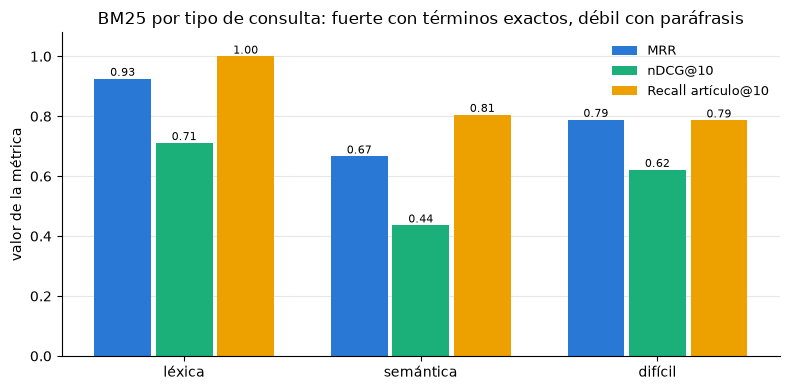

In [9]:
import matplotlib.pyplot as plt
import numpy as np

tipos = ["lexica", "semantica", "dificil"]
metricas = {"MRR": "mrr", "nDCG@10": "ndcg@10", "Recall artículo@10": "recall_articulo@10"}
colores = ["#2a78d6", "#1baf7a", "#eda100"]  # paleta categórica fija, apta para daltonismo

x = np.arange(len(tipos))
ancho = 0.24

fig, ax = plt.subplots(figsize=(8, 4))
for i, (nombre, clave) in enumerate(metricas.items()):
    valores = [resultados["por_tipo"][t][clave] for t in tipos]
    barras = ax.bar(x + (i - 1) * (ancho + 0.02), valores, ancho, label=nombre, color=colores[i])
    ax.bar_label(barras, fmt="%.2f", fontsize=8)

ax.set_xticks(x, ["léxica", "semántica", "difícil"])
ax.set_ylim(0, 1.08)
ax.set_ylabel("valor de la métrica")
ax.set_title("BM25 por tipo de consulta: fuerte con términos exactos, débil con paráfrasis")
ax.legend(frameon=False, fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [10]:
# Las consultas donde BM25 más falla (por rango recíproco): materia prima
# del análisis de errores del Hito 6.
por_consulta = pd.DataFrame(
    [{k: v for k, v in c.items() if k != "top"} for c in resultados["por_consulta"]]
)

peor = min(resultados["por_consulta"], key=lambda c: (c["rr"], c["query_id"]))
print(f"Peor consulta ({peor['query_id']}, tipo {peor['tipo']}): {peor['query']!r}")
print(f"Artículos relevantes: {peor['relevant_source_ids']}")
print("Top 5 recuperado:")
for r in peor["top"][:5]:
    print(f"  #{r['rank']}  {r['source_id']:<28} score={r['score']}")

por_consulta.nsmallest(6, "rr")[["query_id", "tipo", "query", "rr", "recall_articulo@10"]]

Peor consulta (q12, tipo semantica): 'cómo puntuar la pertinencia de un texto frente a las palabras buscadas'
Artículos relevantes: ['bm25']
Top 5 recuperado:
  #1  motor_busqueda               score=20.8849
  #2  entropia                     score=19.0862
  #3  analisis_sentimiento         score=17.4953
  #4  analisis_sentimiento         score=17.1346
  #5  bert                         score=16.6389


,query_id,tipo,query,rr,recall_articulo@10
11,q12,semantica,cómo puntuar la pertinencia de un texto frente...,0.000000,0.000000
19,q20,semantica,hacer que una máquina aprenda a partir de ejem...,0.000000,0.000000
41,q42,semantica,palabras muy frecuentes que se descartan al co...,0.000000,0.000000
52,q53,dificil,algoritmos supervisados para clasificar textos,0.166667,0.333333
25,q26,dificil,métricas para evaluar la calidad de un sistema...,0.200000,0.500000
12,q13,semantica,representar palabras como vectores numéricos q...,0.250000,0.500000


### 2.3 Lectura de los resultados

- **Léxicas: casi techo.** MRR 0.93 y cobertura de artículo perfecta desde k=3 (recall de artículo@3 = 1.0). Cuando la consulta comparte términos con el documento, la línea base es muy difícil de superar.
- **Semánticas: el punto débil esperado.** MRR cae a 0.67 y nDCG@10 a 0.44. Los fallos totales (RR = 0) son paráfrasis sin coincidencia literal: p. ej. *"cómo puntuar la pertinencia de un texto frente a las palabras buscadas"* no comparte términos con el artículo de Okapi BM25 y el ranking se va a *motor de búsqueda*. Esta es exactamente la brecha que el recuperador denso (Hito 4) debería cerrar: la hipótesis queda planteada y es medible.
- **Difíciles: cuestión de profundidad.** La cobertura de artículo sube de 0.31 en k=1 a 0.79 en k=10: al ser consultas multi-artículo, un solo resultado nunca alcanza y el método necesita profundidad para cubrir todas las fuentes relevantes.
- **Costo.** Construir el índice toma ~0.15 s y ocupa ~0.6 MB serializado; la consulta responde en menos de 1 ms. BM25 fija un listón de eficiencia muy alto: el denso y el híbrido tendrán que justificar con calidad cada milisegundo y megabyte extra.

**Para la defensa oral:** qué controlan `k1` (saturación de la frecuencia) y `b` (normalización por longitud); qué mide MRR (posición del primer acierto) frente a nDCG (calidad de todo el orden del top-k); y por qué el recall se mide a nivel de artículo mientras precisión/nDCG se miden a nivel de fragmento.

## 3. Recuperador denso (Hito 4)

## 4. Recuperador híbrido con RRF (Hito 5)

## 5. Evaluación comparativa y análisis de errores (Hito 6)

## 6. Conclusiones y limitaciones